In [1]:
%pip install langgraph langchain-openai langchain-tavily tavily-python

Note: you may need to restart the kernel to use updated packages.


In [2]:
# %pip install litellm
# %pip install -U crewai

In [3]:
import os
from langchain_openai import AzureChatOpenAI
from dotenv import load_dotenv

load_dotenv()


True

In [4]:
# Tavily API Key
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")

llm = AzureChatOpenAI( 
    deployment_name=os.environ["AZURE_OPENAI_CHAT_DEPLOYMENT"],   # gpt-5-mini 
    api_key=os.environ["AZURE_OPENAI_API_KEY"], 
    azure_endpoint=os.environ["AZURE_OPENAI_ENDPOINT"],     # APIM gateway endpoint 
    api_version=os.environ["AZURE_OPENAI_API_VERSION"], 
    temperature=1
)

In [5]:
# Build Tavily Search Tool 
 
from langchain_tavily import TavilySearch 
from langchain.tools import tool

@tool 
def search_tool(query: str): 
    """Use this tool to search the web via Tavily API""" 
    tavily_search_tool = TavilySearch(max_results=3) 
    result = tavily_search_tool.invoke(query) 
    return result 

In [6]:
# Create a Reactive Agent with LangGraph and attach the Tavily tool 
# from langgraph.prebuilt import create_react_agent 
from langchain.agents import create_agent
agent = create_agent(model=llm, tools=[search_tool]) 

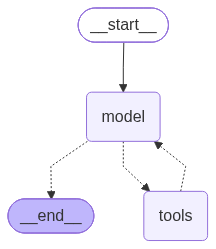

In [7]:
#Run the following command to visualize the graph: 
agent 

In [8]:
 #Run the following code with the Tavily tool (real-time search): 
 
# Execute the agent WITH the search tool 
state = agent.invoke({ 
    "messages": [ 
        {"role": "user", "content": "What are the latest fraud detection methods in UPI systems?"} 
    ] 
}) 
 
print("\n[With Tavily Search Tool]:\n", state) 


[With Tavily Search Tool]:
 {'messages': [HumanMessage(content='What are the latest fraud detection methods in UPI systems?', additional_kwargs={}, response_metadata={}, id='79e31fdf-6bdd-45e3-b0e8-4eacc0ee810d'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 870, 'prompt_tokens': 142, 'total_tokens': 1012, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 640, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}, 'latency_checkpoint': {'engine_tbt_ms': 9, 'engine_ttft_ms': 41, 'engine_ttlt_ms': 7927, 'pre_inference_ms': 127, 'service_tbt_ms': 9, 'service_ttft_ms': 626, 'service_ttlt_ms': 8507, 'total_duration_ms': 8389, 'user_visible_ttft_ms': 499}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-E4a9W47jU9TyEMO99bhMpI8QV1cMF', '

In [9]:
#Run the following code without the Tavily tool (pure LLM reasoning): 
 
# Execute the agent WITHOUT the search tool (pure LLM reasoning) 
state = agent.invoke({ 
    "messages": [ 
        {"role": "user", "content": "What is 2 + 3?"} 
    ] 
}) 
 
print("\n[Without Tool]:\n", state) 


[Without Tool]:
 {'messages': [HumanMessage(content='What is 2 + 3?', additional_kwargs={}, response_metadata={}, id='683778ab-2c8d-4b17-8d85-6a37fe593ca9'), AIMessage(content='5', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 138, 'total_tokens': 149, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}, 'latency_checkpoint': {'engine_tbt_ms': 8, 'engine_ttft_ms': 25, 'engine_ttlt_ms': 246, 'pre_inference_ms': 151, 'service_tbt_ms': 9, 'service_ttft_ms': 384, 'service_ttlt_ms': 592, 'total_duration_ms': 454, 'user_visible_ttft_ms': 232}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-E4a9x0aUw5aVffxzYKg97TXhs1AV5', 'service_tier': 'default', 'prompt_filter_results': [{'prompt_i